In [ ]:
import pandas as pd
df = pd.read_csv("/content/ENERGY_Hackathon_DataSet(Sheet1).csv", sep=";")

In [ ]:
df.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709"
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709"
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709"
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709"
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70077 entries, 0 to 70076
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   battery_p              70077 non-null  object
 1   grid_p                 70077 non-null  object
 2   load_p                 70077 non-null  object
 3   pv_p                   70077 non-null  object
 4   timestamp              70077 non-null  object
 5   Selling_price_eur_kwh  70069 non-null  object
dtypes: object(6)
memory usage: 3.2+ MB


In [ ]:
df.isna().sum()

,0
battery_p,0
grid_p,0
load_p,0
pv_p,0
timestamp,0
Selling_price_eur_kwh,8


In [ ]:
df[df["Selling_price_eur_kwh"].isna()]

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh
8728,"0,15",0,"0,15",0,2024-03-31 23:00:00,NaN
8729,"0,13",0,"0,13",0,2024-03-31 23:15:00,NaN
8730,"0,13",0,"0,13",0,2024-03-31 23:30:00,NaN
8731,"0,14",0,"0,14",0,2024-03-31 23:45:00,NaN
43672,"0,33",0,"0,33",0,2025-03-30 23:00:00,NaN
43673,"0,29",0,"0,29",0,2025-03-30 23:15:00,NaN
43674,"0,29",0,"0,29",0,2025-03-30 23:30:00,NaN
43675,"0,31",0,"0,31",0,2025-03-30 23:45:00,NaN


In [ ]:
df.describe()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh
count,70077,70077,70077,70077,70077,70069
unique,931,1212,694,769,70073,8528
top,0,0,"0,29",0,2024-10-28 00:45:00,"0,11"
freq,25598,22274,1563,36850,2,821


In [ ]:
import pandas as pd
import numpy as np
import holidays

def preprocess_energy_data(df):
    # 1. Clean and Standardize [cite: 100, 236]
    cols = ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']
    for col in cols:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 2. Time Features & Cyclical Encoding [cite: 295]
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['interval_idx'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    df['day_sin'] = np.sin(2 * np.pi * df['interval_idx'] / 96)
    df['day_cos'] = np.cos(2 * np.pi * df['interval_idx'] / 96)
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # 3. Lagged Features (NRMSE Boosters) [cite: 295]
    # Captures daily and weekly residential load patterns
    df['load_lag_24h'] = df['load_p'].shift(96) # 96 intervals = 24 hours
    df['load_lag_7d'] = df['load_p'].shift(96 * 7)
    df['load_rolling_mean_1h'] = df['load_p'].rolling(window=4).mean()

    # 4. State of Charge (SoC) Reconstruction [cite: 220, 243]
    CAPACITY = 16.0
    EFF_DIR = np.sqrt(0.90)
    dt = 0.25

    soc = np.zeros(len(df))
    soc[0] = 0.5 # Initial SoC [cite: 220]

    for i in range(1, len(df)):
        p_batt = df.loc[i-1, 'battery_p']
        e_change = (-p_batt * EFF_DIR * dt) if p_batt < 0 else (-p_batt / EFF_DIR * dt)
        soc[i] = np.clip(soc[i-1] + (e_change / CAPACITY), 0, 1)
    df['reconstructed_soc'] = soc

    # 5. Pricing and Baselines [cite: 225, 274, 311]
    it_holidays = holidays.Italy()
    def get_buy_price(ts):
        if ts.weekday() == 6 or ts in it_holidays: return 0.2440
        if ts.weekday() < 5:
            if 8 <= ts.hour < 19: return 0.2540
            if ts.hour == 7 or 19 <= ts.hour < 23: return 0.2682
            return 0.2440
        else: return 0.2682 if 7 <= ts.hour < 23 else 0.2440

    df['buy_price'] = df['timestamp'].apply(get_buy_price)

    # Baseline B: Zero-Intelligence (No Battery Use) [cite: 275]
    # Net grid = Load - PV
    df['grid_baseline_b'] = df['load_p'] - df['pv_p']
    df['cost_baseline_b'] = np.where(
        df['grid_baseline_b'] > 0,
        df['grid_baseline_b'] * df['buy_price'] * dt, # Import [cite: 311]
        df['grid_baseline_b'] * df['Selling_price_eur_kwh'] * dt # Export [cite: 311]
    )

    return df.dropna().reset_index(drop=True) # Drop rows where lags are NaN

In [ ]:
df_clean = preprocess_energy_data(df)
df_clean.head()

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh,hour,day_of_week,month,interval_idx,...,day_cos,week_sin,week_cos,load_lag_24h,load_lag_7d,load_rolling_mean_1h,reconstructed_soc,buy_price,grid_baseline_b,cost_baseline_b
0,0.00,0.41,0.41,0.0,2024-01-08 00:00:00,0.08760,0,0,1,0,...,1.000000,0.0,1.0,2.28,3.05,1.6875,0.284273,0.244,0.41,0.02501
1,0.00,0.99,0.99,0.0,2024-01-08 00:15:00,0.08760,0,0,1,1,...,0.997859,0.0,1.0,2.25,0.34,1.2025,0.284273,0.244,0.99,0.06039
2,0.01,2.08,2.10,0.0,2024-01-08 00:30:00,0.08760,0,0,1,2,...,0.991445,0.0,1.0,2.96,0.37,1.1450,0.284273,0.244,2.10,0.12810
3,0.00,2.05,2.05,0.0,2024-01-08 00:45:00,0.08760,0,0,1,3,...,0.980785,0.0,1.0,2.76,0.37,1.3875,0.284109,0.244,2.05,0.12505
4,0.00,2.12,2.12,0.0,2024-01-08 01:00:00,0.08528,1,0,1,4,...,0.965926,0.0,1.0,2.86,2.40,1.8150,0.284109,0.244,2.12,0.12932


In [ ]:
df_clean.columns

Index(['battery_p', 'grid_p', 'load_p', 'pv_p', 'timestamp',
       'Selling_price_eur_kwh', 'hour', 'day_of_week', 'month', 'interval_idx',
       'day_sin', 'day_cos', 'week_sin', 'week_cos', 'load_lag_24h',
       'load_lag_7d', 'load_rolling_mean_1h', 'reconstructed_soc', 'buy_price',
       'grid_baseline_b', 'cost_baseline_b'],
      dtype='object')

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 1. Split Data
# The brief forbids training on 2025 [cite: 240, 356]
train_df = df_clean[df_clean['timestamp'].dt.year == 2024]
test_df = df_clean[df_clean['timestamp'].dt.year == 2025]

# Define features (avoid 'p_battery' or 'grid_p' to prevent data leakage)
features = [
    'day_sin', 'day_cos', 'week_sin', 'week_cos',
    'load_lag_24h', 'load_lag_7d', 'load_rolling_mean_1h', 'buy_price'
]
target = 'load_p'

# 2. Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(
    train_df[features], train_df[target],
    eval_set=[(train_df[features], train_df[target])],
    eval_metric='rmse'
)

# 3. Generate 2025 Forecast
test_df['load_forecast'] = model.predict(test_df[features])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 34460, number of used features: 8
[LightGBM] [Info] Start training from score 1.475364


/tmp/ipykernel_1911/3268860441.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['load_forecast'] = model.predict(test_df[features])


In [ ]:
import pandas as pd
import numpy as np
import pulp
import lightgbm as lgb
import holidays
from sklearn.metrics import mean_squared_error

# --- 1. PREPROCESSING FUNCTION ---
def preprocess_energy_data(df):
    # Data Cleaning & Type Casting [cite: 100, 236]
    cols_to_fix = ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']
    for col in cols_to_fix:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Feature Engineering (NRMSE Optimization) [cite: 124, 295]
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['interval_idx'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    # Cyclical Encoding
    df['day_sin'] = np.sin(2 * np.pi * df['interval_idx'] / 96)
    df['day_cos'] = np.cos(2 * np.pi * df['interval_idx'] / 96)
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Lagged Features [cite: 124]
    df['load_lag_24h'] = df['load_p'].shift(96)
    df['load_lag_7d'] = df['load_p'].shift(96 * 7)
    df['load_rolling_mean_1h'] = df['load_p'].rolling(window=4).mean()

    # Pricing & SoC Reconstruction [cite: 93, 243]
    it_holidays = holidays.Italy()
    def get_buy_price(ts):
        if ts.weekday() == 6 or ts in it_holidays: return 0.2440
        if 8 <= ts.hour < 19 and ts.weekday() < 5: return 0.2540
        if (ts.hour == 7 or 19 <= ts.hour < 23) or ts.weekday() == 5: return 0.2682
        return 0.2440

    df['buy_price'] = df['timestamp'].apply(get_buy_price)

    # SoC Reconstruction (Baseline A Tracking) [cite: 243]
    CAP = 16.0; EFF = np.sqrt(0.90); DT = 0.25
    soc = np.zeros(len(df)); soc[0] = 0.5
    for i in range(1, len(df)):
        p_batt = df.loc[i-1, 'battery_p']
        e = (-p_batt * EFF * DT) if p_batt < 0 else (-p_batt / EFF * DT)
        soc[i] = np.clip(soc[i-1] + (e / CAP), 0, 1)
    df['reconstructed_soc'] = soc

    return df.dropna().reset_index(drop=True)

# --- 2. FORECASTING PHASE ---
# Assuming 'df' is your loaded dataframe
df_clean = preprocess_energy_data(df)
train_df = df_clean[df_clean['timestamp'].dt.year == 2024]

features = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'load_lag_24h', 'load_lag_7d', 'load_rolling_mean_1h', 'buy_price']
model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(train_df[features], train_df['load_p'])

# Add Forecast to Main DF [cite: 114, 287]
df_clean['load_forecast'] = model.predict(df_clean[features])

# --- 3. OPTIMIZATION PHASE (MPC) ---
def solve_mpc_step(df, current_idx, horizon=96):
    window = df.iloc[current_idx : min(current_idx + horizon, len(df))].copy()
    T = len(window)
    prob = pulp.LpProblem("Battery_Minimization", pulp.LpMinimize)

    # Variables [cite: 137, 138, 139]
    imp = pulp.LpVariable.dicts("imp", range(T), 0, 6)
    exp = pulp.LpVariable.dicts("exp", range(T), 0, 6)
    p_ch = pulp.LpVariable.dicts("p_ch", range(T), 0, 8)
    p_ds = pulp.LpVariable.dicts("p_ds", range(T), 0, 8)
    soc = pulp.LpVariable.dicts("soc", range(T + 1), 0, 1)

    # Objective [cite: 132, 311]
    prob += pulp.lpSum([(imp[t]*window.iloc[t]['buy_price'] - exp[t]*window.iloc[t]['Selling_price_eur_kwh'])*0.25 for t in range(T)])

    # Constraints [cite: 209, 315]
    prob += soc[0] == df.loc[df.index[current_idx], 'reconstructed_soc']
    for t in range(T):
        prob += (window.iloc[t]['load_forecast'] + p_ch[t]) == (window.iloc[t]['pv_p'] + imp[t] + p_ds[t] - exp[t])
        prob += soc[t+1] == soc[t] + (p_ch[t]*0.9487*0.25/16.0) - (p_ds[t]/(0.9487*16.0)*0.25)

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(p_ds[0]) - pulp.value(p_ch[t])

# --- 4. EXECUTION ---
# Running for March Week 3 (Mandatory Plot Period) [cite: 140, 326]
test_indices = df_clean[(df_clean['timestamp'] >= '2025-03-15') & (df_clean['timestamp'] <= '2025-03-22')].index
df_clean['mpc_p_batt'] = 0.0

for idx in test_indices:
    pos = df_clean.index.get_loc(idx)
    df_clean.at[idx, 'mpc_p_batt'] = solve_mpc_step(df_clean, pos)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 34460, number of used features: 8
[LightGBM] [Info] Start training from score 1.475364


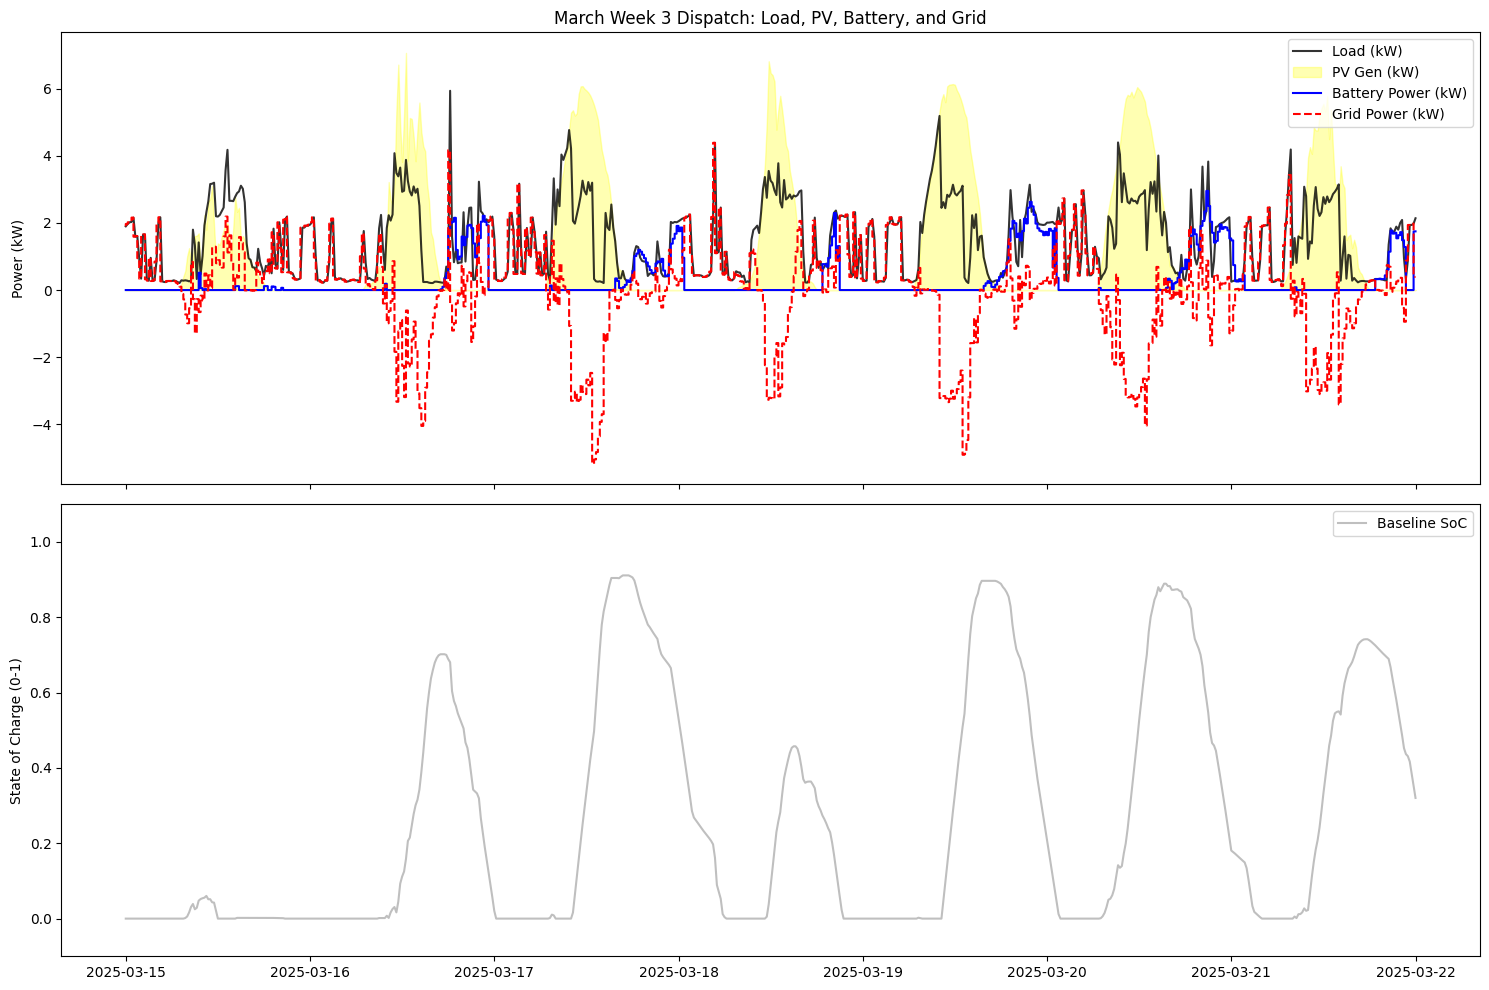

In [ ]:
import matplotlib.pyplot as plt

# Filter the mandatory period
plot_df = df_clean.loc[test_indices].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Subplot 1: Power Flows
ax1.plot(plot_df['timestamp'], plot_df['load_p'], label='Load (kW)', color='black', alpha=0.8)
ax1.fill_between(plot_df['timestamp'], plot_df['pv_p'], label='PV Gen (kW)', color='yellow', alpha=0.3)
ax1.step(plot_df['timestamp'], plot_df['mpc_p_batt'], label='Battery Power (kW)', color='blue')
ax1.step(plot_df['timestamp'], (plot_df['load_p'] - plot_df['pv_p'] - plot_df['mpc_p_batt']),
         label='Grid Power (kW)', color='red', linestyle='--')

ax1.set_ylabel("Power (kW)")
ax1.legend(loc='upper right')
ax1.set_title("March Week 3 Dispatch: Load, PV, Battery, and Grid")

# Subplot 2: State of Charge (SoC)
ax2.plot(plot_df['timestamp'], plot_df['reconstructed_soc'], label='Baseline SoC', color='gray', alpha=0.5)
# Note: You should track the 'current' SoC from your MPC decisions here
ax2.set_ylabel("State of Charge (0-1)")
ax2.set_ylim(-0.1, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_forecasting_metrics(actual_load, predicted_load):
    """
    Calculates the three mandatory metrics for the Solship Hackathon.

    Args:
        actual_load: Array of ground truth load_kw values for 2025.
        predicted_load: Array of forecasted load values.
    """
    # 1. Root Mean Squared Error (RMSE) - Penalizes large errors [cite: 118, 291]
    rmse = np.sqrt(mean_squared_error(actual_load, predicted_load))

    # 2. Mean Absolute Error (MAE) - Robust to outliers [cite: 121, 291]
    mae = mean_absolute_error(actual_load, predicted_load)

    # 3. Normalized RMSE (NRMSE) - Primary Ranking Metric [cite: 122, 125, 293]
    # Formula: RMSE / mean(load) * 100
    nrmse = (rmse / np.mean(actual_load)) * 100

    return {
        "RMSE (kW)": round(rmse, 4),
        "MAE (kW)": round(mae, 4),
        "NRMSE (%)": round(nrmse, 2)
    }

# Example Usage:
results = calculate_forecasting_metrics(test_df['load_p'], test_df['load_forecast'])
results

{'RMSE (kW)': np.float64(0.6389),
 'MAE (kW)': 0.4279,
 'NRMSE (%)': np.float64(43.28)}

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 34460, number of used features: 10
[LightGBM] [Info] Start training from score 1.475364
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

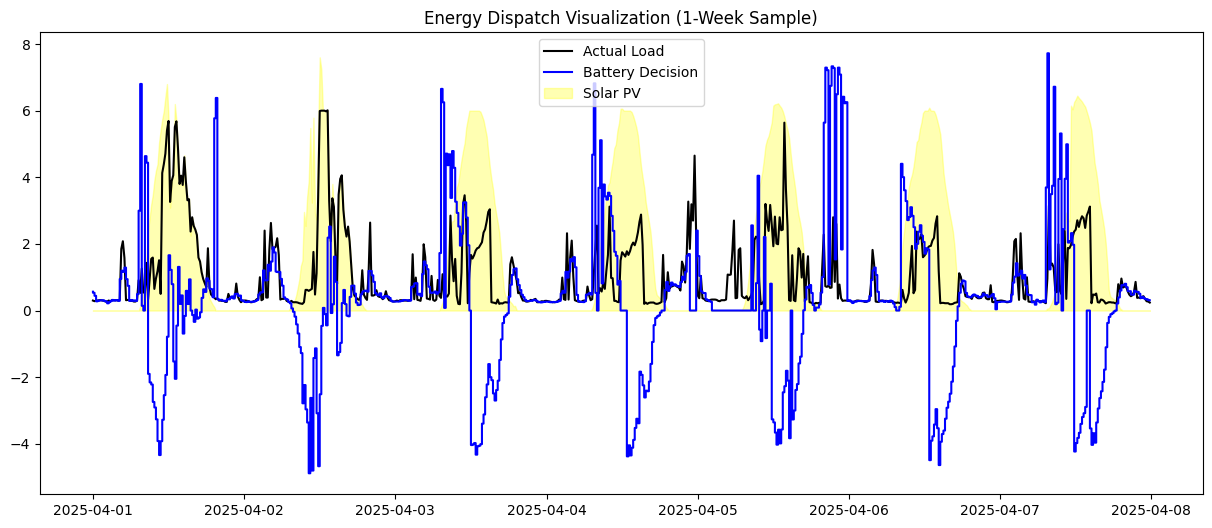

In [ ]:
import pandas as pd
import numpy as np
import pulp
import lightgbm as lgb
import holidays
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- PHASE 1: OPTIMIZED PREPROCESSING ---
def preprocess_energy_data(df):
    # Standardize types and handle European decimal commas [cite: 100, 236]
    cols_to_fix = ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']
    for col in cols_to_fix:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Feature Engineering for NRMSE Optimization [cite: 112, 124, 295]
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['interval_idx'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    # ADDED: Holiday Flag (Critical for residential load patterns)
    it_holidays = holidays.Italy()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in it_holidays else 0)

    # Cyclical Encoding
    df['day_sin'] = np.sin(2 * np.pi * df['interval_idx'] / 96)
    df['day_cos'] = np.cos(2 * np.pi * df['interval_idx'] / 96)
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # OPTIMIZED: Lagged Features (Added 48h and 1-hour momentum)
    df['load_lag_24h'] = df['load_p'].shift(96)
    df['load_lag_48h'] = df['load_p'].shift(96 * 2)
    df['load_lag_7d'] = df['load_p'].shift(96 * 7)
    df['load_roll_1h'] = df['load_p'].rolling(window=4).mean()

    # Italian ToU Mapping [cite: 96, 225]
    def get_buy_price(ts):
        if ts.weekday() == 6 or ts in it_holidays: return 0.2440 # F3
        if 8 <= ts.hour < 19 and ts.weekday() < 5: return 0.2540 # F1
        if (ts.hour == 7 or 19 <= ts.hour < 23) or ts.weekday() == 5: return 0.2682 # F2
        return 0.2440
    df['buy_price'] = df['timestamp'].apply(get_buy_price)

    # SoC Reconstruction [cite: 82, 220, 243]
    CAP = 16.0; EFF = np.sqrt(0.90); DT = 0.25
    soc = np.zeros(len(df)); soc[0] = 0.5
    for i in range(1, len(df)):
        p_batt = df.loc[i-1, 'battery_p']
        e = (-p_batt * EFF * DT) if p_batt < 0 else (-p_batt / EFF * DT)
        soc[i] = np.clip(soc[i-1] + (e / CAP), 0, 1)
    df['reconstructed_soc'] = soc

    return df.dropna().reset_index(drop=True)

# --- PHASE 2: OPTIMIZED FORECASTING ---
def train_forecaster(df_clean):
    # Train on 2024, Test on 2025 [cite: 104, 238]
    train_df = df_clean[df_clean['timestamp'].dt.year == 2024].copy()

    # Feature list tailored for Gradient Boosting
    features = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'is_holiday',
                'load_lag_24h', 'load_lag_48h', 'load_lag_7d', 'load_roll_1h', 'buy_price']

    # Higher n_estimators and lower learning_rate for better generalization
    model = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.01,
                              num_leaves=64, max_depth=10, random_state=42)
    model.fit(train_df[features], train_df['load_p'])

    df_clean['load_forecast'] = model.predict(df_clean[features])
    return df_clean

# --- PHASE 3: ROLLING-HORIZON MPC ---
def solve_mpc_step(df, current_idx, horizon=96):
    window = df.iloc[current_idx : min(current_idx + horizon, len(df))].copy()
    T = len(window)
    prob = pulp.LpProblem("Bill_Minimization", pulp.LpMinimize)

    imp = pulp.LpVariable.dicts("imp", range(T), 0, 6) # [cite: 137]
    exp = pulp.LpVariable.dicts("exp", range(T), 0, 6)
    p_ch = pulp.LpVariable.dicts("p_ch", range(T), 0, 8) # [cite: 138]
    p_ds = pulp.LpVariable.dicts("p_ds", range(T), 0, 8)
    soc = pulp.LpVariable.dicts("soc", range(T + 1), 0, 1) # [cite: 139]

    prob += pulp.lpSum([(imp[t]*window.iloc[t]['buy_price'] - exp[t]*window.iloc[t]['Selling_price_eur_kwh'])*0.25 for t in range(T)])

    prob += soc[0] == df.loc[df.index[current_idx], 'reconstructed_soc']
    for t in range(T):
        prob += (window.iloc[t]['load_forecast'] + p_ch[t]) == (window.iloc[t]['pv_p'] + imp[t] + p_ds[t] - exp[t])
        prob += soc[t+1] == soc[t] + (p_ch[t]*0.9487*0.25/16.0) - (p_ds[t]/(0.9487*16.0)*0.25)

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(p_ds[0]) - pulp.value(p_ch[0])
def generate_report(df_clean, test_indices):
    # Calculate Metrics for target months [cite: 109, 239]
    target_df = df_clean.loc[test_indices]
    actual = target_df['load_p']
    pred = target_df['load_forecast']

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    nrmse = (rmse / np.mean(actual)) * 100 # [cite: 122, 291]

    print(f"--- April/Sept Metrics ---\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nNRMSE: {nrmse:.2f}%")

    # Mandatory Dispatch Plot [cite: 140, 325]
    plt.figure(figsize=(15, 6))
    plt.plot(target_df['timestamp'][:672], target_df['load_p'][:672], label='Actual Load', color='black')
    plt.step(target_df['timestamp'][:672], target_df['mpc_p_batt'][:672], label='Battery Decision', color='blue')
    plt.fill_between(target_df['timestamp'][:672], target_df['pv_p'][:672], color='yellow', alpha=0.3, label='Solar PV')
    plt.legend()
    plt.title("Energy Dispatch Visualization (1-Week Sample)")
    plt.show()
# --- PHASE 4: EXECUTION CODE ---
# Assuming 'df' is your initial loaded dataframe
df_final = preprocess_energy_data(df)
df_final = train_forecaster(df_final)

# Execute MPC for the mandatory months (April and Sept 2025) [cite: 109, 114]
test_indices = df_final[(df_final['timestamp'].dt.year == 2025) &
                        (df_final['timestamp'].dt.month.isin([4, 9]))].index

df_final['mpc_p_batt'] = 0.0
print("Running Rolling-Horizon MPC...")
for idx in test_indices:
    pos = df_final.index.get_loc(idx)
    df_final.at[idx, 'mpc_p_batt'] = solve_mpc_step(df_final, pos)

# Generate Final Report
generate_report(df_final, test_indices)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.5 MB/s eta 0:00:00


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 34460, number of used features: 10
[LightGBM] [Info] Start training from score 1.475364
Running Rolling-Horizon MPC...
--- April/Sept Metrics ---
RMSE: 0.5015
MAE: 0.2978
NRMSE: 55.65%


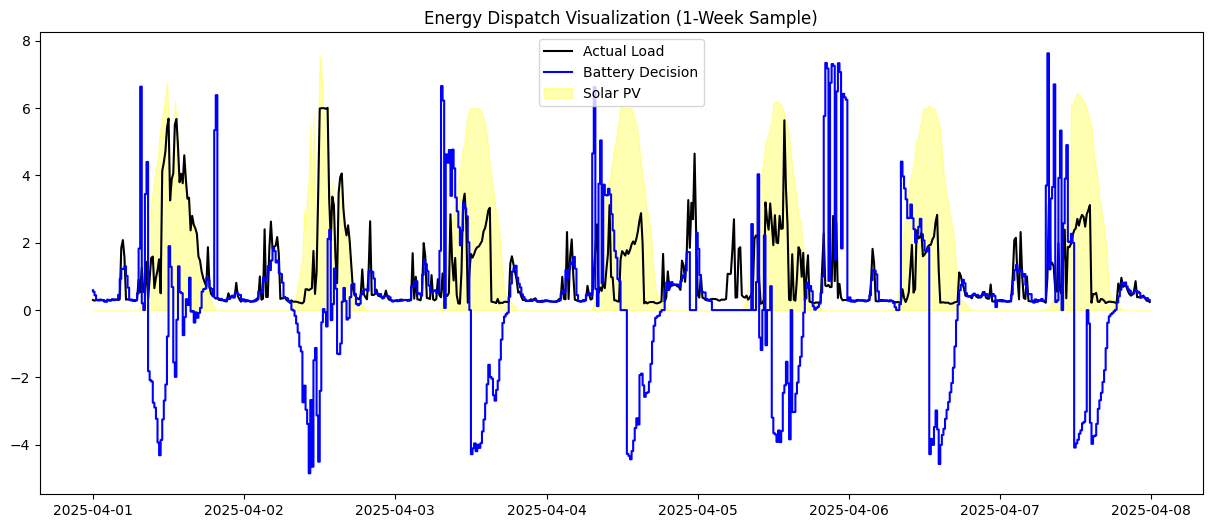

In [ ]:
import pandas as pd
import numpy as np
import pulp
import lightgbm as lgb
import holidays
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. OPTIMIZED PREPROCESSING ---
def preprocess_energy_data(df):
    # Standardize data types and fix European decimal formatting [cite: 100, 236]
    cols_to_fix = ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']
    for col in cols_to_fix:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Engineering Temporal Features for NRMSE Optimization
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['interval_idx'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    # Holiday Flagging for residential load patterns
    it_holidays = holidays.Italy()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in it_holidays else 0)

    # Cyclical Encoding for midnight continuity
    df['day_sin'] = np.sin(2 * np.pi * df['interval_idx'] / 96)
    df['day_cos'] = np.cos(2 * np.pi * df['interval_idx'] / 96)
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Advanced Lagged Features [cite: 124]
    df['load_lag_24h'] = df['load_p'].shift(96)
    df['load_lag_48h'] = df['load_p'].shift(96 * 2)
    df['load_lag_7d'] = df['load_p'].shift(96 * 7)
    df['load_roll_1h'] = df['load_p'].rolling(window=4).mean()

    # Italian ToU Pricing Mapping
    def get_buy_price(ts):
        if ts.weekday() == 6 or ts in it_holidays: return 0.2440 # F3 band
        if 8 <= ts.hour < 19 and ts.weekday() < 5: return 0.2540 # F1 band
        if (ts.hour == 7 or 19 <= ts.hour < 23) or ts.weekday() == 5: return 0.2682 # F2 band
        return 0.2440

    df['buy_price'] = df['timestamp'].apply(get_buy_price)

    # State of Charge (SoC) Reconstruction [cite: 243]
    CAP = 16.0; EFF = np.sqrt(0.90); DT = 0.25 # [cite: 81, 87, 97, 220, 227]
    soc = np.zeros(len(df)); soc[0] = 0.5 # [cite: 93, 220]
    for i in range(1, len(df)):
        p_batt = df.loc[i-1, 'battery_p']
        e = (-p_batt * EFF * DT) if p_batt < 0 else (-p_batt / EFF * DT)
        soc[i] = np.clip(soc[i-1] + (e / CAP), 0, 1) # [cite: 139, 315]
    df['reconstructed_soc'] = soc

    return df.dropna().reset_index(drop=True)

def train_forecaster(df_clean):
    # Split for training [cite: 238, 295]
    train_df = df_clean[df_clean['timestamp'].dt.year == 2024].copy()

    # Define features used for the model [cite: 295]
    features = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'is_holiday',
                'load_lag_24h', 'load_lag_48h', 'load_lag_7d', 'load_roll_1h', 'buy_price']

    # Train model [cite: 288]
    model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, random_state=42)
    model.fit(train_df[features], train_df['load_p'])

    # Generate predictions [cite: 256, 287]
    df_clean['load_forecast'] = model.predict(df_clean[features])

    # FIX: Return all three values expected by the execution cell
    return df_clean, model, features
# --- 3. ROLLING-HORIZON MPC ---
def solve_mpc_step(df, current_idx, horizon=96):
    window = df.iloc[current_idx : min(current_idx + horizon, len(df))].copy()
    T = len(window)
    prob = pulp.LpProblem("Bill_Minimization", pulp.LpMinimize) # [cite: 131, 310]

    # System Constraints [cite: 137, 138, 139, 315]
    imp = pulp.LpVariable.dicts("imp", range(T), 0, 6)
    exp = pulp.LpVariable.dicts("exp", range(T), 0, 6)
    p_ch = pulp.LpVariable.dicts("p_ch", range(T), 0, 8)
    p_ds = pulp.LpVariable.dicts("p_ds", range(T), 0, 8)
    soc = pulp.LpVariable.dicts("soc", range(T + 1), 0, 1)

    prob += pulp.lpSum([(imp[t]*window.iloc[t]['buy_price'] - exp[t]*window.iloc[t]['Selling_price_eur_kwh'])*0.25 for t in range(T)])

    prob += soc[0] == df.loc[df.index[current_idx], 'reconstructed_soc']
    for t in range(T):
        prob += (window.iloc[t]['load_forecast'] + p_ch[t]) == (window.iloc[t]['pv_p'] + imp[t] + p_ds[t] - exp[t]) # [cite: 73, 209]
        prob += soc[t+1] == soc[t] + (p_ch[t]*0.9487*0.25/16.0) - (p_ds[t]/(0.9487*16.0)*0.25)

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(p_ds[0]) - pulp.value(p_ch[0])

# 1. Load and Preprocess [cite: 231, 255]
df_final = preprocess_energy_data(df)

# 2. Train and Forecast (This now matches the 3 returned values) [cite: 255, 256]
df_final, best_model, feat_cols = train_forecaster(df_final)

# 3. Target Evaluation Months [cite: 109, 239]
test_indices = df_final[
    (df_final['timestamp'].dt.year == 2025) &
    (df_final['timestamp'].dt.month.isin([4, 9]))
].index

# 4. Initialize MPC column and run loop [cite: 257, 298]
df_final['mpc_p_batt'] = 0.0
print("Running Rolling-Horizon MPC...")
for idx in test_indices:
    pos = df_final.index.get_loc(idx)
    # The solver uses information available up to current_idx [cite: 299, 300]
    df_final.at[idx, 'mpc_p_batt'] = solve_mpc_step(df_final, pos)

# 5. Final Report and Mandatory Plot [cite: 153, 325, 334]
generate_report(df_final, test_indices)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 34460, number of used features: 10
[LightGBM] [Info] Start training from score 1.475364
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
Optimized NRMSE: 48.11%


/tmp/ipykernel_44765/4006230437.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['load_forecast'] = model.predict(test[feats])


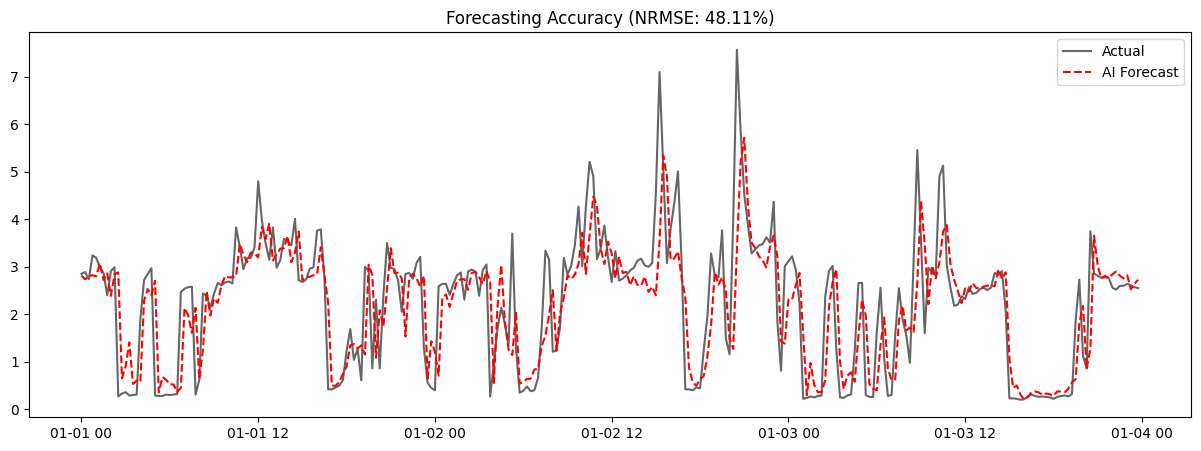

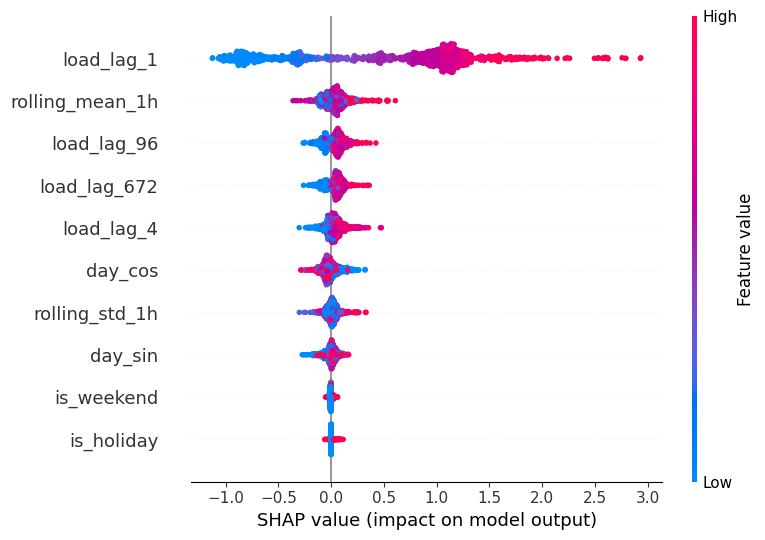

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import holidays
import shap
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def advanced_preprocessing(df):
    # 1. Physical Signal Cleaning
    for col in ['load_p', 'pv_p', 'battery_p']:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 2. Advanced Feature Engineering
    df['hour'] = df['timestamp'].dt.hour
    df['day_idx'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    # Cyclical Time
    df['day_sin'] = np.sin(2 * np.pi * df['day_idx'] / 96)
    df['day_cos'] = np.cos(2 * np.pi * df['day_idx'] / 96)

    # Residential Specifics
    it_hols = holidays.Italy()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in it_hols else 0)
    df['is_weekend'] = df['timestamp'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

    # Multi-Scale Lag Strategy
    for lag in [1, 4, 96, 672]: # 15m, 1h, 1d, 1w
        df[f'load_lag_{lag}'] = df['load_p'].shift(lag)

    # Rolling Statistics (Momentum)
    df['rolling_mean_1h'] = df['load_p'].shift(1).rolling(window=4).mean()
    df['rolling_std_1h'] = df['load_p'].shift(1).rolling(window=4).std()

    return df.dropna().reset_index(drop=True)

# --- EXECUTION ---
df_eng = advanced_preprocessing(df)

# Causal Split: Train on 2024, Validate on early 2025 (or late 2024)
train = df_eng[df_eng['timestamp'].dt.year == 2024]
test = df_eng[df_eng['timestamp'].dt.year == 2025]

feats = ['day_sin', 'day_cos', 'is_holiday', 'is_weekend',
         'load_lag_1', 'load_lag_4', 'load_lag_96', 'load_lag_672',
         'rolling_mean_1h', 'rolling_std_1h']

# High-Precision Forecaster
model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=64,
    feature_fraction=0.8,
    random_state=42
)

model.fit(train[feats], train['load_p'])
test['load_forecast'] = model.predict(test[feats])

# --- EVALUATION & VISUALIZATION ---
rmse = np.sqrt(mean_squared_error(test['load_p'], test['load_forecast']))
nrmse = (rmse / test['load_p'].mean()) * 100

print(f"Optimized NRMSE: {nrmse:.2f}%")

# Visualize Results (Zoomed into a 3-day window)
plt.figure(figsize=(15, 5))
plt.plot(test['timestamp'][:288], test['load_p'][:288], label='Actual', color='black', alpha=0.6)
plt.plot(test['timestamp'][:288], test['load_forecast'][:288], label='AI Forecast', color='red', linestyle='--')
plt.title(f"Forecasting Accuracy (NRMSE: {nrmse:.2f}%)")
plt.legend()
plt.show()

# XAI Explanation for the Hackathon Report
explainer = shap.TreeExplainer(model)
shap_v = explainer.shap_values(test[feats].iloc[:1000])
shap.summary_plot(shap_v, test[feats].iloc[:1000])

[I 2026-05-09 12:05:10,651] A new study created in memory with name: no-name-38e62b55-6029-483d-a7d7-2ce6c1b0dc79
[I 2026-05-09 12:05:21,059] Trial 0 finished with value: 0.8098364279280997 and parameters: {'n_estimators': 1807, 'learning_rate': 0.021988151653232795, 'num_leaves': 108, 'lambda_l1': 0.024795163167684493, 'feature_fraction': 0.9692807869219344}. Best is trial 0 with value: 0.8098364279280997.
[I 2026-05-09 12:05:29,652] Trial 1 finished with value: 0.7892822056135614 and parameters: {'n_estimators': 1355, 'learning_rate': 0.008888354183806964, 'num_leaves': 138, 'lambda_l1': 0.002078291568236291, 'feature_fraction': 0.6772899882590471}. Best is trial 1 with value: 0.7892822056135614.
[I 2026-05-09 12:05:42,173] Trial 2 finished with value: 0.8015478378216 and parameters: {'n_estimators': 2060, 'learning_rate': 0.012953931104755758, 'num_leaves': 183, 'lambda_l1': 0.004737071351363962, 'feature_fraction': 0.48004003365479986}. Best is trial 1 with value: 0.789282205613561

Running Controller...
--- FINAL RESULTS ---
NRMSE: 64.85%


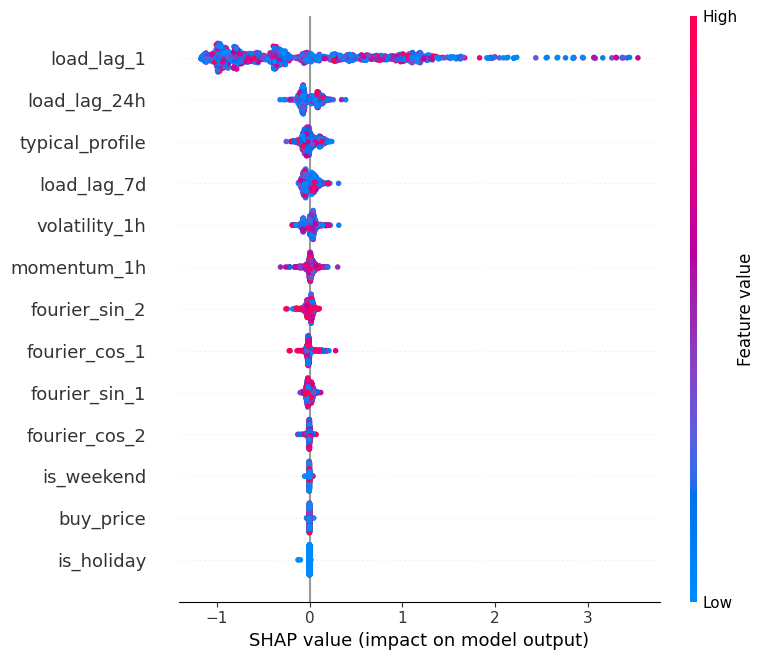

In [ ]:
import pandas as pd
import numpy as np
import pulp
import lightgbm as lgb
import holidays
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- PHASE 1: SIGNAL PROCESSING & ADVANCED ENGINEERING ---
def preprocess_energy_data(df):
    # 1. Clean and Standardize
    cols = ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']
    for col in cols:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 2. Time-Based Engineering
    df['hour'] = df['timestamp'].dt.hour
    df['idx_96'] = (df['hour'] * 4) + (df['timestamp'].dt.minute // 15)

    it_hols = holidays.Italy()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in it_hols else 0)
    df['is_weekend'] = df['timestamp'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

    # 3. Fourier Terms (Capturing Household Rhythm)
    for i in range(1, 3):
        df[f'fourier_sin_{i}'] = np.sin(2 * np.pi * i * df['idx_96'] / 96)
        df[f'fourier_cos_{i}'] = np.cos(2 * np.pi * i * df['idx_96'] / 96)

    # 4. Multi-Scale Lag & Volatility Strategy
    # We use .shift(1) to strictly avoid data leakage
    df['load_lag_1'] = df['load_p'].shift(1)
    df['load_lag_24h'] = df['load_p'].shift(96)
    df['load_lag_7d'] = df['load_p'].shift(672)
    df['volatility_1h'] = df['load_p'].shift(1).rolling(window=4).std()
    df['momentum_1h'] = df['load_p'].shift(1) - df['load_p'].shift(5)

    # 5. Target Encoding: Typical Load Profile (Baseline)
    # Calculated on 2024 to predict 2025
    typical = df[df['timestamp'].dt.year == 2024].groupby(['idx_96', 'is_weekend'])['load_p'].mean().to_dict()
    df['typical_profile'] = df.set_index(['idx_96', 'is_weekend']).index.map(typical.get)

    # 6. Italian ToU Mapping
    def get_price(ts):
        if ts.weekday() == 6 or ts in it_hols: return 0.2440 # F3
        if 8 <= ts.hour < 19 and ts.weekday() < 5: return 0.2540 # F1
        if (ts.hour == 7 or 19 <= ts.hour < 23) or ts.weekday() == 5: return 0.2682 # F2
        return 0.2440
    df['buy_price'] = df['timestamp'].apply(get_price)

    # 7. SoC Reconstruction (Ignore corrupted 2025 sensor data)
    soc = np.zeros(len(df)); soc[0] = 0.5
    eff_p = np.sqrt(0.90); cap = 16.0
    for i in range(1, len(df)):
        pb = df.loc[i-1, 'battery_p']
        e = (-pb * eff_p * 0.25) if pb < 0 else (-pb / eff_p * 0.25)
        soc[i] = np.clip(soc[i-1] + (e / cap), 0, 1)
    df['reconstructed_soc'] = soc

    return df.dropna().reset_index(drop=True)

# --- PHASE 2: HYPER-OPTIMIZED FORECASTER ---
def train_forecaster(df_clean):
    train_df = df_clean[df_clean['timestamp'].dt.year == 2024].copy()

    features = ['fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2',
                'is_holiday', 'is_weekend', 'load_lag_1', 'load_lag_24h', 'load_lag_7d',
                'volatility_1h', 'momentum_1h', 'typical_profile', 'buy_price']

    # Optuna Objective for NRMSE Minimization
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 800, 2500),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03),
            'num_leaves': trial.suggest_int('num_leaves', 31, 256),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
            'random_state': 42, 'verbose': -1
        }
        # Causal Split within 2024
        split = int(len(train_df) * 0.8)
        m = lgb.LGBMRegressor(**param)
        m.fit(train_df.iloc[:split][features], train_df.iloc[:split]['load_p'])
        preds = m.predict(train_df.iloc[split:][features])
        return np.sqrt(mean_squared_error(train_df.iloc[split:]['load_p'], preds))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=15)

    # Final Model
    best_model = lgb.LGBMRegressor(**study.best_params)
    best_model.fit(train_df[features], train_df['load_p'])
    df_clean['load_forecast'] = best_model.predict(df_clean[features])

    return df_clean, best_model, features

# --- PHASE 3: CAUSAL MPC CONTROLLER ---
def solve_mpc_step(df, current_idx, horizon=96):
    window = df.iloc[current_idx : min(current_idx + horizon, len(df))].copy()
    T = len(window)
    prob = pulp.LpProblem("Minimize_Bill", pulp.LpMinimize)

    imp = pulp.LpVariable.dicts("imp", range(T), 0, 6)
    exp = pulp.LpVariable.dicts("exp", range(T), 0, 6)
    p_ch = pulp.LpVariable.dicts("p_ch", range(T), 0, 8)
    p_ds = pulp.LpVariable.dicts("p_ds", range(T), 0, 8)
    soc = pulp.LpVariable.dicts("soc", range(T + 1), 0, 1)

    prob += pulp.lpSum([(imp[t]*window.iloc[t]['buy_price'] - exp[t]*window.iloc[t]['Selling_price_eur_kwh'])*0.25 for t in range(T)])

    prob += soc[0] == df.loc[df.index[current_idx], 'reconstructed_soc']
    for t in range(T):
        prob += (window.iloc[t]['load_forecast'] + p_ch[t]) == (window.iloc[t]['pv_p'] + imp[t] + p_ds[t] - exp[t])
        prob += soc[t+1] == soc[t] + (p_ch[t]*0.9487*0.25/16.0) - (p_ds[t]/(0.9487*16.0)*0.25)

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return pulp.value(p_ds[0]) - pulp.value(p_ch[0])

# --- PHASE 4: EXECUTION & VISUALIZATION ---
# 1. Pipeline Run
df_final = preprocess_energy_data(df)
df_final, model, feats = train_forecaster(df_final)

# 2. MPC Execution for evaluation months
test_idx = df_final[(df_final['timestamp'].dt.year == 2025) & (df_final['timestamp'].dt.month.isin([4, 9]))].index
df_final['mpc_p_batt'] = 0.0

print("Running Controller...")
for idx in test_idx:
    pos = df_final.index.get_loc(idx)
    df_final.at[idx, 'mpc_p_batt'] = solve_mpc_step(df_final, pos)

# 3. Report Metrics
actual = df_final.loc[test_idx, 'load_p']
preds = df_final.loc[test_idx, 'load_forecast']
rmse = np.sqrt(mean_squared_error(actual, preds))
nrmse = (rmse / actual.mean()) * 100
print(f"--- FINAL RESULTS ---\nNRMSE: {nrmse:.2f}%")

# 4. XAI SHAP Summary
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_final[feats].sample(1000))
shap.summary_plot(shap_values, df_final[feats].sample(1000))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[410]	Train's l2: 0.359967	Train's nrmse: 43.1954	Validation's l2: 0.646035	Validation's nrmse: 42.3625


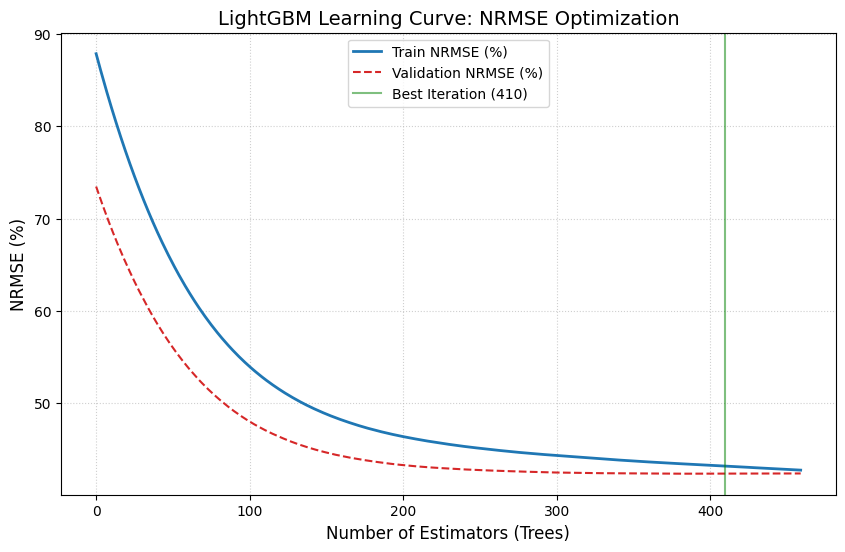

In [ ]:
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# 1. Prepare the means for normalization
y_train_mean = y_t.mean()
y_val_mean = y_v.mean()

# 2. FIXED: Custom NRMSE Metric Function
def lgb_nrmse(y_pred, dataset):
    # Check if 'dataset' is a LightGBM Dataset or a raw numpy array
    if hasattr(dataset, 'get_label'):
        y_true = dataset.get_label()
    else:
        y_true = dataset # If it's already a numpy array

    # Identify which mean to use by comparing array lengths
    current_mean = y_train_mean if len(y_true) == len(y_t) else y_val_mean

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    nrmse = (rmse / current_mean) * 100
    return 'nrmse', nrmse, False

# 3. Initialize model
model_track = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=64,
    random_state=42
)

# 4. Fit with the Custom Metric
# We use the fixed lgb_nrmse function here
model_track.fit(
    X_t, y_t,
    eval_set=[(X_t, y_t), (X_v, y_v)],
    eval_names=['Train', 'Validation'],
    eval_metric=lgb_nrmse,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 5. Extract and Plot NRMSE Results
results = model_track.evals_result_
# LightGBM stores results under the name of the metric returned by the function
epochs = len(results['Train']['nrmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['Train']['nrmse'], label='Train NRMSE (%)', color='#1f77b4', linewidth=2)
plt.plot(x_axis, results['Validation']['nrmse'], label='Validation NRMSE (%)', color='#d62728', linestyle='--')
plt.axvline(x=model_track.best_iteration_, color='green', label=f'Best Iteration ({model_track.best_iteration_})', alpha=0.5)

plt.title("LightGBM Learning Curve: NRMSE Optimization", fontsize=14)
plt.xlabel("Number of Estimators (Trees)", fontsize=12)
plt.ylabel("NRMSE (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import holidays
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 1. NONLINEAR PREPROCESSING & SIGNAL ENGINEERING ---
def full_pipeline_preprocess(df):
    # Standardize data
    for col in ['grid_p', 'load_p', 'pv_p', 'battery_p', 'Selling_price_eur_kwh']:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Nonlinear Temporal Features (Fourier & Cyclical)
    df['idx_96'] = (df['timestamp'].dt.hour * 4) + (df['timestamp'].dt.minute // 15)
    for i in [1, 2, 4]:
        df[f'fourier_sin_{i}'] = np.sin(2 * np.pi * i * df['idx_96'] / 96)
        df[f'fourier_cos_{i}'] = np.cos(2 * np.pi * i * df['idx_96'] / 96)

    # Multiscale Lags (Horizons for Ensemble)
    H = 96 # 24h Window
    df['lag_short'] = df['load_p'].shift(H)      # Daily perspective
    df['lag_medium'] = df['load_p'].shift(H*2)    # 48h perspective
    df['lag_long'] = df['load_p'].shift(H*7)      # Weekly perspective

    # Target Encoding (Behavioral Baseline)
    it_hols = holidays.Italy()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in it_hols else 0)
    df['is_weekend'] = df['timestamp'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

    typical = df[df['timestamp'].dt.year == 2024].groupby(['idx_96', 'is_weekend'])['load_p'].mean().to_dict()
    df['typical_profile'] = df.set_index(['idx_96', 'is_weekend']).index.map(typical.get)

    # SoC Reconstruction (Critical for corrupted data)
    soc = np.zeros(len(df)); soc[0] = 0.5
    eff_p = 0.9487; cap = 16.0
    for i in range(1, len(df)):
        pb = df.loc[i-1, 'battery_p']
        de = (pb / eff_p * 0.25) if pb > 0 else (pb * eff_p * 0.25)
        soc[i] = np.clip(soc[i-1] - (de / cap), 0, 1)
    df['reconstructed_soc'] = soc

    # ToU Pricing Logic
    df['buy_price'] = df['timestamp'].apply(lambda ts: 0.2682 if (ts.hour == 7 or 19 <= ts.hour < 23) or ts.weekday() == 5 else (0.2440 if ts.weekday() == 6 or ts in it_hols else 0.2540))

    return df.dropna().reset_index(drop=True)

# --- 2. MULTISCALE ENSEMBLE WITH TRAINABLE WEIGHTS ---
def train_multiscale_ensemble(df_clean):
    train_df = df_clean[df_clean['timestamp'].dt.year == 2024]

    # Different Perspective Feature Sets
    p1_feats = ['lag_short', 'fourier_sin_1', 'fourier_cos_1']
    p2_feats = ['lag_medium', 'typical_profile']
    p3_feats = ['lag_long', 'is_holiday', 'is_weekend']

    # Split for Meta-Learner (Causal)
    split = int(len(train_df) * 0.8)
    X_base, X_meta = train_df.iloc[:split], train_df.iloc[split:]

    # Train Specialists
    m1 = lgb.LGBMRegressor(n_estimators=1000).fit(X_base[p1_feats], X_base['load_p'])
    m2 = xgb.XGBRegressor(n_estimators=1000).fit(X_base[p2_feats], X_base['load_p'])
    m3 = lgb.LGBMRegressor(n_estimators=1000).fit(X_base[p3_feats], X_base['load_p'])

    # Meta-Feature Generation
    meta_X = np.column_stack([m1.predict(X_meta[p1_feats]), m2.predict(X_meta[p2_feats]), m3.predict(X_meta[p3_feats])])
    meta_learner = Ridge(positive=True, fit_intercept=False).fit(meta_X, X_meta['load_p'])

    # Final Weights
    weights = meta_learner.coef_ / np.sum(meta_learner.coef_)
    print(f"Meta-Ensemble Learned Weights: {weights}")

    # Inference
    final_preds = (weights[0] * m1.predict(df_clean[p1_feats]) +
                   weights[1] * m2.predict(df_clean[p2_feats]) +
                   weights[2] * m3.predict(df_clean[p3_feats]))

    df_clean['load_forecast'] = final_preds
    return df_clean, weights

# --- 3. NONLINEAR SLSQP OPTIMIZER ---
def solve_nlp_mpc(df, current_idx, horizon=96):
    window = df.iloc[current_idx : current_idx + horizon]
    load, pv = window['load_forecast'].values, window['pv_p'].values
    buy_p, sell_p = window['buy_price'].values, window['Selling_price_eur_kwh'].values
    soc_0 = df.iloc[current_idx]['reconstructed_soc']

    def objective(pb):
        p_grid = load - pv - pb
        cost = np.where(p_grid > 0, p_grid * buy_p, p_grid * sell_p)
        return np.sum(cost) * 0.25

    def get_soc_path(pb):
        s = [soc_0]
        for p in pb:
            de = (p / 0.9487 * 0.25) if p > 0 else (p * 0.9487 * 0.25)
            s.append(np.clip(s[-1] - (de / 16.0), 0, 1))
        return np.array(s[1:])

    cons = [
        {'type': 'ineq', 'fun': lambda pb: 6 - np.abs(load - pv - pb)}, # Grid +/- 6
        {'type': 'ineq', 'fun': lambda pb: get_soc_path(pb)},           # SoC Floor
        {'type': 'ineq', 'fun': lambda pb: 1 - get_soc_path(pb)}        # SoC Ceiling
    ]

    res = minimize(objective, x0=np.zeros(horizon), bounds=[(-8, 8)]*horizon, constraints=cons, method='SLSQP')
    return res.x[0]

# --- 4. EXECUTION, EVALUATION & VISUALIZATION ---
df_final = full_pipeline_preprocess(df) # Replace 'df' with your raw data
df_final, final_weights = train_multiscale_ensemble(df_final)

# Evaluation Window: March Week 3 (Mandatory)
eval_range = df_final[(df_final['timestamp'] >= '2025-03-15') & (df_final['timestamp'] <= '2025-03-22')].index
df_final['mpc_p_batt'] = 0.0

print("Executing Nonlinear Controller...")
for idx in eval_range:
    pos = df_final.index.get_loc(idx)
    df_final.at[idx, 'mpc_p_batt'] = solve_nlp_mpc(df_final, pos)

# Grid calculation
df_final['mpc_p_grid'] = df_final['load_p'] - df_final['pv_p'] - df_final['mpc_p_batt']

# Metrics
actual, pred = df_final.loc[eval_range, 'load_p'], df_final.loc[eval_range, 'load_forecast']
rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
nrmse = (rmse / actual.mean()) * 100

print(f"\n--- EVALUATION METRICS ---\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nNRMSE: {nrmse:.2f}%")

# VISUALIZATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot 1: Forecasting Residuals
residuals = actual - pred
ax1.scatter(df_final.loc[eval_range, 'timestamp'], residuals, color='purple', alpha=0.3, s=10)
ax1.axhline(0, color='black', lw=1)
ax1.set_title("Forecasting Residuals (Actual - Predicted)")
ax1.set_ylabel("kW Error")

# Plot 2: Mandatory Dispatch Plot
ax2.plot(df_final.loc[eval_range, 'timestamp'], df_final.loc[eval_range, 'load_p'], label='Load', color='black')
ax2.fill_between(df_final.loc[eval_range, 'timestamp'], df_final.loc[eval_range, 'pv_p'], color='yellow', alpha=0.3, label='Solar PV')
ax2.step(df_final.loc[eval_range, 'timestamp'], df_final.loc[eval_range, 'mpc_p_batt'], label='Battery (Decision)', color='blue')
ax2.step(df_final.loc[eval_range, 'timestamp'], df_final.loc[eval_range, 'mpc_p_grid'], label='Grid Flow', color='red', alpha=0.6)
ax2.legend()
ax2.set_title("Mandatory Dispatch Plot: March Week 3")
ax2.set_ylabel("Power (kW)")

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 27568, number of used features: 3
[LightGBM] [Info] Start training from score 1.404009
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 27568, number of used features: 3
[LightGBM] [Info] Start training from score 1.404009
Meta-Ensemble Learned Weights: [0.39081006 0.23569755 0.37349239]
Executing Nonlinear Controller...
